In [58]:
import pandas as pd
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
# read file from input
df = pd.read_csv('Iris.csv')

In [60]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [61]:
# Do linear regression , L1 Regularization , L2 regulization and compare the accuracy sources of test and train score

In [62]:
X = df[['sepal_length', 'sepal_width', 'petal_length']]
y = df['petal_width']


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (120, 3)
X_test shape: (30, 3)
y_train shape: (120,)
y_test shape: (30,)


In [63]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [64]:
y_pred_lr = linear_model.predict(X_test)

In [65]:
print(y_pred_lr)

[1.57270267 0.30069703 2.32427051 1.51344473 1.45986481 0.16753234
 1.12555804 1.66997768 1.29579814 1.19040344 1.78942142 0.15939885
 0.06070059 0.21357853 0.3360775  1.64660942 2.11652255 1.18938503
 1.56050934 1.98437627 0.33911894 1.72863586 0.31635044 1.98437627
 2.29989764 1.74692586 1.94746818 2.14742454 0.15939885 0.29103592]


In [66]:
lr_train_score = linear_model.score(X_train, y_train)

In [67]:
lr_test_score = linear_model.score(X_test , y_test)

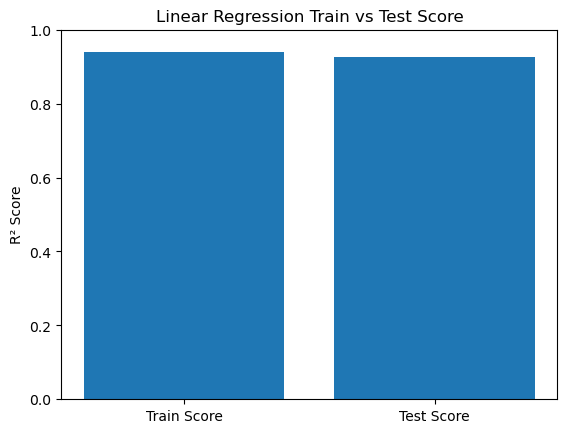

In [68]:
## For linear regression 
scores = [lr_train_score, lr_test_score]
labels = ["Train Score", "Test Score"]

plt.figure()
plt.bar(labels, scores)
plt.ylabel("R² Score")
plt.title("Linear Regression Train vs Test Score")
plt.ylim(0, 1)  # since R² ranges -∞ to 1
plt.show()

Lasso Regression model trained successfully.
[1.50524017 0.50964067 2.23534648 1.43886687 1.53842682 0.44326736
 1.14018702 1.63798678 1.43886687 1.23974697 1.63798678 0.41008071
 0.37689406 0.44326736 0.44326736 1.50524017 1.87029333 1.23974697
 1.43886687 1.80392003 0.47645402 1.57161347 0.47645402 1.80392003
 2.06941323 1.67117343 1.87029333 1.90347998 0.41008071 0.47645402]


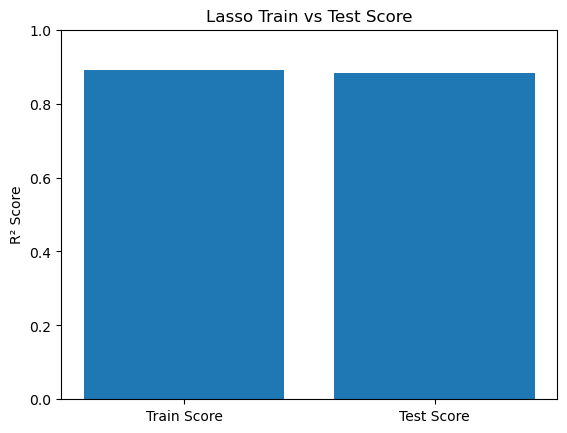

In [69]:
from sklearn.linear_model import Lasso

# Initialize the Lasso Regression model with alpha=0.01
lasso_model = Lasso(alpha=0.25, random_state=42)

# Train the model using the training data
lasso_model.fit(X_train, y_train)


print("Lasso Regression model trained successfully.")


y_pred_lasso = lasso_model.predict(X_test)
print(y_pred_lasso)


lasso_train_score = lasso_model.score(X_train, y_train)
lasso_test_score = lasso_model.score(X_test, y_test)

lasso_scores = [lasso_train_score, lasso_test_score]
labels = ["Train Score", "Test Score"]

plt.figure()
plt.bar(labels, lasso_scores)
plt.ylabel("R² Score")
plt.title("Lasso Train vs Test Score")
plt.ylim(0, 1)  # since R² ranges -∞ to 1
plt.show()


Ridge Regression model trained successfully.
[1.572783   0.30395949 2.33110667 1.5125661  1.4671956  0.17281562
 1.12562661 1.67348438 1.30447706 1.19299387 1.78739511 0.16273282
 0.06726902 0.21638585 0.3338155  1.64370997 2.11235823 1.1918209
 1.5573093  1.98238732 0.33803342 1.72541875 0.31654155 1.98238732
 2.29946028 1.74862928 1.95077186 2.14393289 0.16273282 0.29211724]


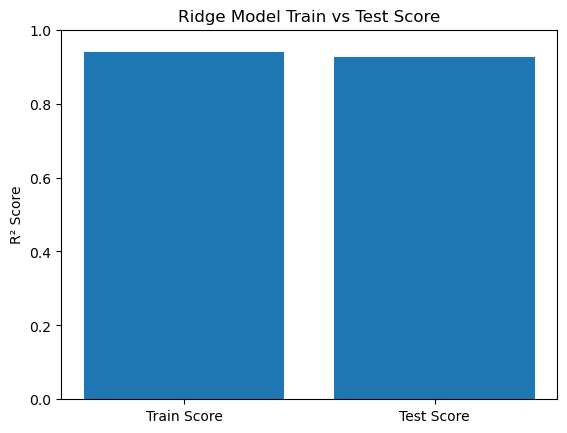

In [70]:
from sklearn.linear_model import Ridge

# Initialize the Ridge Regression model with alpha=0.01
ridge_model = Ridge(alpha=0.25, random_state=42)

# Train the model using the training data
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")




y_pred_ridge = ridge_model.predict(X_test)
print(y_pred_ridge)


ridge_train_score = ridge_model.score(X_train, y_train)
ridge_test_score = ridge_model.score(X_test, y_test)



ridge_scores = [ridge_train_score, ridge_test_score]
labels = ["Train Score", "Test Score"]

plt.figure()
plt.bar(labels, ridge_scores)
plt.ylabel("R² Score")
plt.title("Ridge Model Train vs Test Score")
plt.ylim(0, 1)  # since R² ranges -∞ to 1
plt.show()


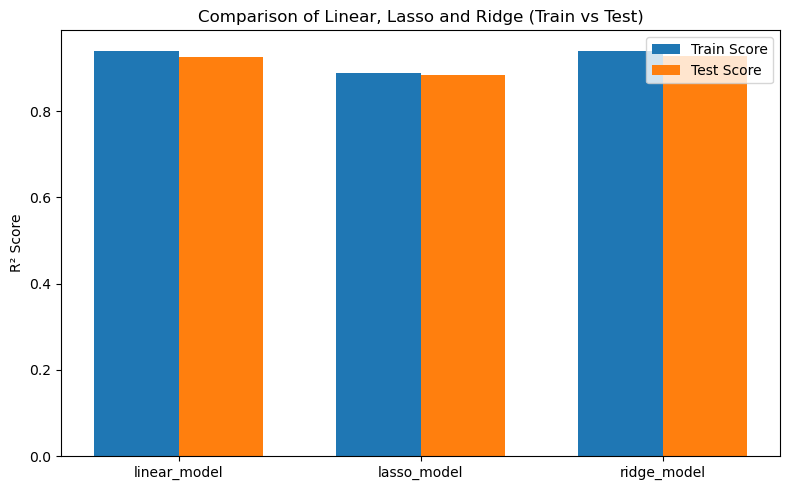

In [71]:
# plotting 3 graphs together 

import numpy as np


models = ["linear_model", "lasso_model", "ridge_model"]

# Scores
train_scores = [lr_train_score, lasso_train_score, ridge_train_score]
test_scores  = [lr_test_score,  lasso_test_score,  ridge_test_score]

x = np.arange(len(models))  # positions for bars
width = 0.35  # bar width

plt.figure(figsize=(8,5))

plt.bar(x - width/2, train_scores, width, label="Train Score")
plt.bar(x + width/2, test_scores, width, label="Test Score")

plt.xticks(x, models)
plt.ylabel("R² Score")
plt.title("Comparison of Linear, Lasso and Ridge (Train vs Test)")
plt.legend()

plt.tight_layout()
plt.show()